In [ ]:
# CELL 1 — GOOGLE COLAB + DRIVE SETUP
import sys, os

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print('Running on Google Colab')
    from google.colab import drive
    drive.mount('/content/drive')

    # CONFIGURE YOUR DRIVE PATHS HERE
    WORK_DIR    = '/content/drive/MyDrive/MAJOR'
    DATA_DIR    = '/content/drive/MyDrive/MAJOR/data'
    FIGURES_DIR = '/content/drive/MyDrive/MAJOR/figures'
    TABLES_DIR  = '/content/drive/MyDrive/MAJOR/tables'
    MODELS_DIR  = '/content/drive/MyDrive/MAJOR/models'


    for d in [WORK_DIR, DATA_DIR, FIGURES_DIR, TABLES_DIR, MODELS_DIR]:
        os.makedirs(d, exist_ok=True)
    os.chdir(WORK_DIR)

    import subprocess
    subprocess.run([
        'pip', 'install', '-q',
        'scikit-survival', 'scikit-learn', 'imbalanced-learn',
        'pandas', 'numpy', 'matplotlib', 'seaborn', 'tqdm', 'shap','lifelines'
    ], check=True)

else:
    print('Not on Colab — using local paths')
    WORK_DIR    = os.getcwd()
    DATA_DIR    = WORK_DIR
    FIGURES_DIR = os.path.join(WORK_DIR, 'figures')
    TABLES_DIR  = os.path.join(WORK_DIR, 'tables')
    MODELS_DIR  = os.path.join(WORK_DIR, 'models')
    for d in [FIGURES_DIR, TABLES_DIR, MODELS_DIR]:
        os.makedirs(d, exist_ok=True)

print(f'Data    : {DATA_DIR}')
print(f'Figures : {FIGURES_DIR}')
print(f'Tables  : {TABLES_DIR}')
print(f'Models  : {MODELS_DIR}')
print('Setup complete!')

Running on Google Colab
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data    : /content/drive/MyDrive/MAJOR/data
Figures : /content/drive/MyDrive/MAJOR/figures
Tables  : /content/drive/MyDrive/MAJOR/tables
Models  : /content/drive/MyDrive/MAJOR/models
Setup complete!


In [ ]:
# CELL 2 — IMPORTS & GLOBAL SEEDS
import warnings
warnings.filterwarnings('ignore')
import os, random, time, pickle
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm.auto import tqdm
from scipy.cluster.hierarchy import linkage, leaves_list

# scikit-survival — True Random Survival Forest
from sksurv.ensemble import RandomSurvivalForest
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import (
    concordance_index_censored,
    cumulative_dynamic_auc,
    integrated_brier_score,
    brier_score
)
from sksurv.util import Surv
# imbalanced-learn — SMOTE

from imblearn.over_sampling import SMOTE

# sklearn
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve
)

import shap
import joblib

# ── Global seeds for full reproducibility ──
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# ── Plot styling ──
plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 11,
    'axes.titlesize': 13, 'axes.labelsize': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
})
C = {'hr': '#C0392B', 'lr': '#2980B9', 'neu': '#7F8C8D',
     'gold': '#F39C12', 'green': '#27AE60', 'purple': '#8E44AD'}

print(f'All libraries loaded   |  SEED = {SEED}')
print(f'NumPy {np.__version__} | Pandas {pd.__version__} | Matplotlib {matplotlib.__version__}')

All libraries loaded   |  SEED = 42
NumPy 2.0.2 | Pandas 2.2.2 | Matplotlib 3.10.0


PREPROCESSING

In [ ]:
OUTPUT_DIR = '/content/drive/MyDrive/MAJOR/processed'
os.makedirs(OUTPUT_DIR, exist_ok=True)

SEED = 42
np.random.seed(SEED)

print(f'Data source : {os.path.abspath(DATA_DIR)}')
print(f'Output dir  : {os.path.abspath(OUTPUT_DIR)}')


Data source : /content/drive/MyDrive/MAJOR/data
Output dir  : /content/drive/MyDrive/MAJOR/processed


In [ ]:
#LOAD RAW DATASETS
raw     = pd.read_csv(os.path.join(DATA_DIR, 'data_raw.csv'))
vessels = pd.read_csv(os.path.join(DATA_DIR, 'data_vessels.csv'))

print(f'[LOAD] data_raw.csv     : {raw.shape[0]} rows × {raw.shape[1]} cols')
print(f'[LOAD] data_vessels.csv : {vessels.shape[0]} rows × {vessels.shape[1]} cols')

[LOAD] data_raw.csv     : 4817 rows × 28 cols
[LOAD] data_vessels.csv : 4817 rows × 3 cols


In [ ]:
#MERGE ON PATIENT IDENTIFIER
df = pd.merge(raw, vessels[['N. patients', 'Creatinina']], on='N. patients', how='left')
print(f'[MERGE] Shape after merge : {df.shape}')
assert df.shape[0] == raw.shape[0], ' Row count changed after merge — check key column'


[MERGE] Shape after merge : (4817, 29)


In [ ]:
#VESSEL TRANSLATION  (Vessels = Vessels + 1)
df['Vessels'] = df['Vessels'] + 1
print(f'  Value counts (NaN = missing):\n{df["Vessels"].value_counts(dropna=False).sort_index().to_string()}')

  Value counts (NaN = missing):
Vessels
1.0     153
1.5     284
2.0    1346
3.0    1066
4.0     727
5.0     159
NaN    1082


In [ ]:
#REMOVE NON-CARDIOVASCULAR DEATHS
n_before  = len(df)
mask_excl = (df['Total mortality'] == 1) & (df['CVD Death'] == 0)
df        = df[~mask_excl].reset_index(drop=True)
n_removed = n_before - len(df)
print(f'[FILTER] Removed {n_removed} non-CVD deaths | Remaining: {len(df)} patients')

nan_creat = df['Creatinina'].isna().sum()
nan_vess  = df['Vessels'].isna().sum()
df['Creatinina'] = df['Creatinina'].fillna(0)
df['Vessels']    = df['Vessels'].fillna(0)
print(f'[IMPUTE] Creatinina: {nan_creat} NaNs → 0')
print(f'[IMPUTE] Vessels   : {nan_vess} NaNs → 0')

[FILTER] Removed 830 non-CVD deaths | Remaining: 3987 patients
[IMPUTE] Creatinina: 220 NaNs → 0
[IMPUTE] Vessels   : 794 NaNs → 0


In [ ]:
#RENAME COLUMNS

rename_map = {
    'Gender (Male = 1)'                          : 'Gender',
    'FE'                                          : 'LVEF',
    'Documented resting \nor exertional ischemia' : 'Ischemia',
    'Post-ischemic Dilated\nCardiomyopathy'       : 'Post_IDC',
    'Smoke\nHistory of smoke'                     : 'Smoke',
    'Diabetes\nHistory of diabetes'               : 'Diabetes',
    'Hypertension\nHistory of hypertension'       : 'Hypertension',
    'Hyperlipemia\nHistoty of hyperlipemia'        : 'Dyslipidemia',
    'Paroxysmal or chronic \natrial fibrillation' : 'AF',
    'Previous Myocardial Infarction'              : 'PMI',
    'Acute Myocardial Infarction'                 : 'AMI',
    'Previous CABG'                               : 'Previous_CABG',
    'Previous PCI'                                : 'Previous_PCI',
    'Durata Follow Up'                            : 'Time',
    'CVD Death'                                   : 'Event',
}
df = df.rename(columns=rename_map)

# 18 clinical features
FEATURES_18 = [
    'Gender', 'Age', 'Angina', 'Previous_CABG', 'Previous_PCI',
    'PMI', 'AMI', 'LVEF', 'Ischemia', 'Post_IDC',
    'Smoke', 'Diabetes', 'Hypertension', 'Dyslipidemia',
    'AF', 'Creatinina', 'Angiography', 'Vessels'
]
CONTINUOUS_FEATURES = ['Age', 'LVEF', 'Vessels', 'Creatinina']
BINARY_FEATURES     = [f for f in FEATURES_18 if f not in CONTINUOUS_FEATURES]
CONT_IDX            = [FEATURES_18.index(f) for f in CONTINUOUS_FEATURES]

df_final = df[FEATURES_18 + ['Time', 'Event']].copy()
print(f'[SELECT] 18 features + Time + Event  →  shape: {df_final.shape}')
print(f'  Continuous : {CONTINUOUS_FEATURES}')
print(f'  Binary     : {BINARY_FEATURES}')

[SELECT] 18 features + Time + Event  →  shape: (3987, 20)
  Continuous : ['Age', 'LVEF', 'Vessels', 'Creatinina']
  Binary     : ['Gender', 'Angina', 'Previous_CABG', 'Previous_PCI', 'PMI', 'AMI', 'Ischemia', 'Post_IDC', 'Smoke', 'Diabetes', 'Hypertension', 'Dyslipidemia', 'AF', 'Angiography']


In [ ]:
#SURVIVAL VARIABLES + VALIDATION

df_final['Time'] = df_final['Time'] / 12.0
T = df_final['Time'].values.astype(float)
E = df_final['Event'].values.astype(bool)

print(f'[SURVIVAL] Time  : min={T.min():.2f}, max={T.max():.2f}, mean={T.mean():.2f} years')
print(f'           Events: {E.sum()} ({E.mean()*100:.1f}%)  |  Censored: {(~E).sum()} ({(~E).mean()*100:.1f}%)')

#Hard validations
assert len(df_final) == 3987,        f' Expected 3987 patients, got {len(df_final)}'
assert len(FEATURES_18) == 18,       ' Feature count must be exactly 18'
assert 'LVEF' in df_final.columns,   ' FE → LVEF rename failed'
assert df_final['Time'].notna().all(),' Time has NaN values'
assert df_final['Event'].notna().all(),' Event has NaN values'
assert df_final[FEATURES_18].isna().sum().sum() == 0, ' NaN values remain in features'
print(f'   {len(df_final)} patients (expected 3987)')
print(f'   {len(FEATURES_18)} features')
print(f'   Event rate = {E.mean()*100:.1f}%  ← imbalanced (addressed in Phase 2 of main notebook)')
df_final.head()

[SURVIVAL] Time  : min=0.00, max=20.94, mean=6.61 years
           Events: 757 (19.0%)  |  Censored: 3230 (81.0%)
   3987 patients (expected 3987)
   18 features
   Event rate = 19.0%  ← imbalanced (addressed in Phase 2 of main notebook)


,Gender,Age,Angina,Previous_CABG,Previous_PCI,PMI,AMI,LVEF,Ischemia,Post_IDC,Smoke,Diabetes,Hypertension,Dyslipidemia,AF,Creatinina,Angiography,Vessels,Time,Event
0,1,54,1,0,0,0,0,46,1,0,1,0,0,0,0,0.00,1,5.0,5.702500,1
1,1,56,1,1,1,1,0,35,1,1,0,0,0,1,0,0.83,0,0.0,10.051667,0
2,1,61,1,0,0,1,0,48,1,0,0,0,0,1,0,1.10,1,4.0,9.325000,0
3,1,75,1,1,0,1,0,39,1,0,1,0,0,0,0,0.00,0,0.0,0.425833,1
4,1,81,1,1,1,1,0,40,1,1,0,1,1,1,1,1.59,1,4.0,3.609167,1


In [ ]:
#STRATIFIED 60/20/20 SPLIT

X     = df_final[FEATURES_18].values.astype(float)
E_int = E.astype(int)
idx_all = np.arange(len(X))

# First cut: 80% train+val | 20% test
idx_tv, idx_test   = train_test_split(idx_all, test_size=0.20,
                                       random_state=SEED, stratify=E_int)
# Second cut: 75% of 80% = 60% train | 25% of 80% = 20% val
idx_train, idx_val = train_test_split(idx_tv, test_size=0.25,
                                       random_state=SEED, stratify=E_int[idx_tv])

X_train_raw = X[idx_train]
X_val_raw   = X[idx_val]
X_test_raw  = X[idx_test]
T_train, T_val, T_test = T[idx_train], T[idx_val], T[idx_test]
E_train, E_val, E_test = E[idx_train], E[idx_val], E[idx_test]

print(f'Train : {len(idx_train):>5} patients  |  event rate = {E_train.mean()*100:.1f}%')
print(f'Val   : {len(idx_val):>5} patients  |  event rate = {E_val.mean()*100:.1f}%')
print(f'Test  : {len(idx_test):>5} patients  |  event rate = {E_test.mean()*100:.1f}%')

y_surv  = Surv.from_arrays(event=E, time=T)
y_train = y_surv[idx_train]
y_val   = y_surv[idx_val]
y_test  = y_surv[idx_test]

print(f'y_train : {len(y_train)} samples  |  dtype={y_train.dtype}')
print(f'y_val   : {len(y_val)} samples')
print(f'y_test  : {len(y_test)} samples')

Train :  2391 patients  |  event rate = 19.0%
Val   :   798 patients  |  event rate = 18.9%
Test  :   798 patients  |  event rate = 19.0%
y_train : 2391 samples  |  dtype=[('event', '?'), ('time', '<f8')]
y_val   : 798 samples
y_test  : 798 samples


In [ ]:
#FIT SCALER ON TRAIN, TRANSFORM ALL SPLITS

scaler = StandardScaler()

X_train = X_train_raw.copy()
X_val   = X_val_raw.copy()
X_test  = X_test_raw.copy()

#fit on TRAIN only
X_train[:, CONT_IDX] = scaler.fit_transform(X_train_raw[:, CONT_IDX])

#apply SAME parameters to val and test (no refit)
X_val[:,   CONT_IDX] = scaler.transform(X_val_raw[:,   CONT_IDX])
X_test[:,  CONT_IDX] = scaler.transform(X_test_raw[:,  CONT_IDX])

print('Scaler fit on training set only')
print(f'  Train means  (continuous): {scaler.mean_.round(4)}')
print(f'  Train stdevs (continuous): {scaler.scale_.round(4)}')
print(f'  Features scaled : {CONTINUOUS_FEATURES}')
print(f'  Features kept   : {BINARY_FEATURES}')

#Sanity check — binary columns must be unchanged
dm_idx = FEATURES_18.index('Diabetes')
assert X_train[:, dm_idx].mean() == X_train_raw[:, dm_idx].mean(), ' Binary col was scaled!'
print('Binary columns confirmed unchanged')

Scaler fit on training set only
  Train means  (continuous): [68.6771 49.4705  2.1405  1.15  ]
  Train stdevs (continuous): [10.9225 12.3268  1.3955  0.7061]
  Features scaled : ['Age', 'LVEF', 'Vessels', 'Creatinina']
  Features kept   : ['Gender', 'Angina', 'Previous_CABG', 'Previous_PCI', 'PMI', 'AMI', 'Ischemia', 'Post_IDC', 'Smoke', 'Diabetes', 'Hypertension', 'Dyslipidemia', 'AF', 'Angiography']
Binary columns confirmed unchanged


In [ ]:
#SAVE PROCESSED DATASETS

col_order = FEATURES_18 + ['Time', 'Event']

def make_df(X_arr, T_arr, E_arr):
    df_out = pd.DataFrame(X_arr, columns=FEATURES_18)
    df_out['Time']  = T_arr
    df_out['Event'] = E_arr.astype(int)
    return df_out

df_train_out = make_df(X_train, T_train, E_train)
df_val_out   = make_df(X_val,   T_val,   E_val)
df_test_out  = make_df(X_test,  T_test,  E_test)

train_path = os.path.join(OUTPUT_DIR, 'train_processed.csv')
val_path   = os.path.join(OUTPUT_DIR, 'validation_processed.csv')
test_path  = os.path.join(OUTPUT_DIR, 'test_processed.csv')

df_train_out.to_csv(train_path, index=False)
df_val_out.to_csv(val_path,     index=False)
df_test_out.to_csv(test_path,   index=False)


print(f'   train_processed.csv      — {df_train_out.shape[0]} rows × {df_train_out.shape[1]} cols')
print(f'   validation_processed.csv — {df_val_out.shape[0]} rows × {df_val_out.shape[1]} cols')
print(f'   test_processed.csv       — {df_test_out.shape[0]} rows × {df_test_out.shape[1]} cols')
print(f'   Saved to: {os.path.abspath(OUTPUT_DIR)}')
df_train_out.head()

   train_processed.csv      — 2391 rows × 20 cols
   validation_processed.csv — 798 rows × 20 cols
   test_processed.csv       — 798 rows × 20 cols
   Saved to: /content/drive/MyDrive/MAJOR/processed


,Gender,Age,Angina,Previous_CABG,Previous_PCI,PMI,AMI,LVEF,Ischemia,Post_IDC,Smoke,Diabetes,Hypertension,Dyslipidemia,AF,Creatinina,Angiography,Vessels,Time,Event
0,1.0,0.578886,1.0,0.0,0.0,1.0,0.0,0.448574,0.0,0.0,1.0,0.0,1.0,1.0,0.0,-0.495639,0.0,-1.533878,12.085000,0
1,1.0,-0.611318,0.0,1.0,0.0,1.0,0.0,-1.985144,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.637386,1.0,0.615889,6.562500,0
2,0.0,0.670440,1.0,0.0,1.0,0.0,0.0,0.691945,1.0,0.0,0.0,0.0,1.0,1.0,1.0,-0.594779,0.0,-1.533878,2.000000,1
3,1.0,-0.245102,1.0,1.0,0.0,0.0,0.0,-1.579524,0.0,1.0,1.0,0.0,1.0,1.0,0.0,-0.028266,0.0,-1.533878,6.899167,0
4,1.0,-1.343751,0.0,0.0,1.0,1.0,0.0,0.205202,0.0,0.0,1.0,1.0,1.0,0.0,0.0,4.857906,0.0,-1.533878,6.964167,0


SURVIVAL- AWARE TEMPORAL PROGNOSIS

Original training set : 1937 survived, 454 events
After Balanced Bootstrap: 1937 survived, 968 events
After SMOTE            : 2013 survived, 2013 events


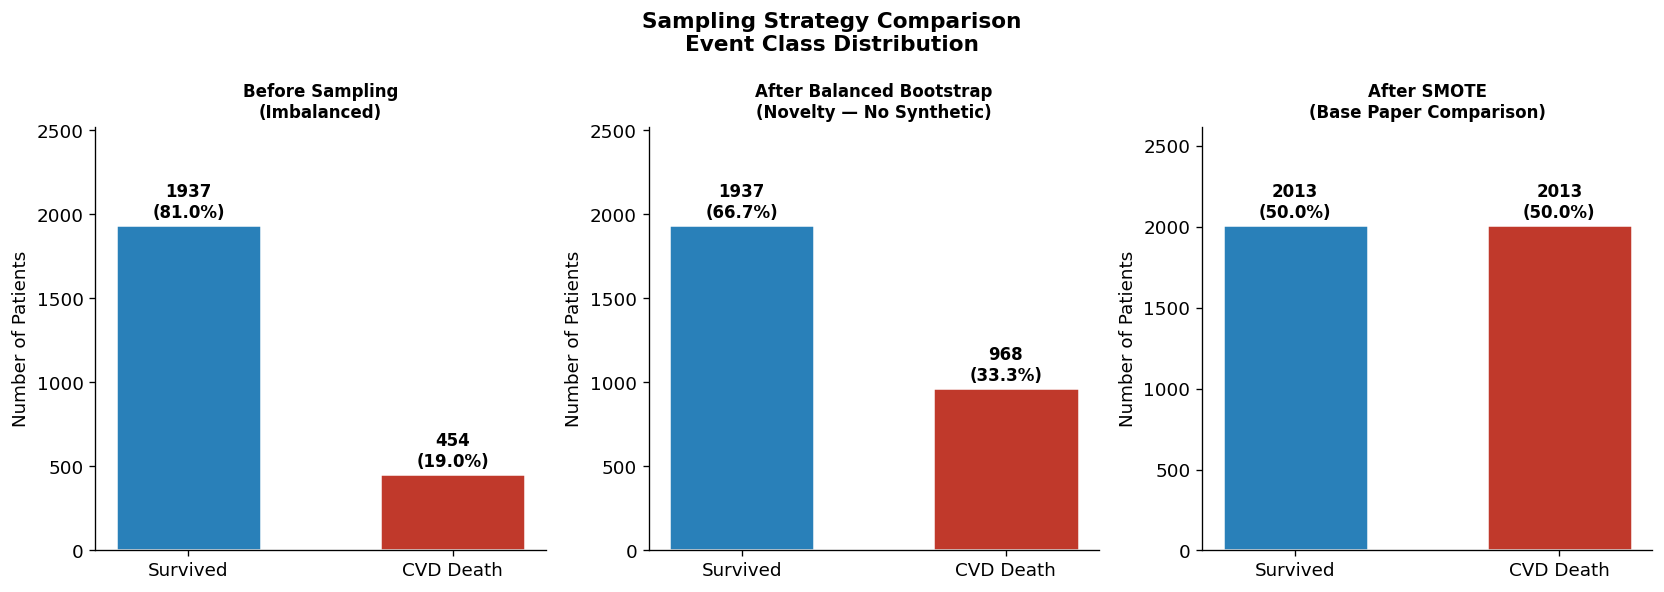

In [ ]:
#SAMPLING STRATEGIES: BALANCED BOOTSTRAP vs SMOTE

#Method A: Balanced Bootstrap
def balanced_bootstrap(X, y_surv_arr, random_state=SEED):

    rng    = np.random.RandomState(random_state)
    events = np.array([r[0] for r in y_surv_arr], dtype=bool)
    idx_maj = np.where(~events)[0]
    idx_min = np.where(events)[0]
    target_minority = len(idx_maj) // 2
    up_idx  = rng.choice(idx_min, size=target_minority, replace=True)
    all_idx = np.concatenate([idx_maj, up_idx])
    rng.shuffle(all_idx)
    return X[all_idx], y_surv_arr[all_idx]

X_bal_bb, y_bal_bb = balanced_bootstrap(X_train, y_train)
E_bal_bb = np.array([r[0] for r in y_bal_bb], dtype=int)

#Method B: SMOTE
HORIZON   = 7.0
y_train5  = ((E_train) & (T_train <= HORIZON)).astype(int)
smote     = SMOTE(random_state=SEED)
X_bal_sm, y_bal_sm5 = smote.fit_resample(X_train, y_train5)

# Reconstruct survival array for SMOTE-balanced set
# Original samples keep their survival times; synthetic samples get mean time
n_orig = len(X_train)
n_new  = len(X_bal_sm) - n_orig
T_mean_event = T_train[E_train].mean()
T_smote_new  = np.full(n_new, T_mean_event)
E_smote_new  = y_bal_sm5[n_orig:].astype(bool)
T_smote_all  = np.concatenate([T_train, T_smote_new])
E_smote_all  = np.concatenate([E_train, E_smote_new])
y_bal_sm     = Surv.from_arrays(event=E_smote_all, time=T_smote_all)

before   = [int((~E_train).sum()), int(E_train.sum())]
after_bb = [int((E_bal_bb==0).sum()), int((E_bal_bb==1).sum())]
after_sm = [int((y_bal_sm5==0).sum()), int((y_bal_sm5==1).sum())]

print(f'Original training set : {before[0]} survived, {before[1]} events')
print(f'After Balanced Bootstrap: {after_bb[0]} survived, {after_bb[1]} events')
print(f'After SMOTE            : {after_sm[0]} survived, {after_sm[1]} events')

#Sampling comparison visualization
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Sampling Strategy Comparison\nEvent Class Distribution',
             fontsize=13, fontweight='bold')

datasets = [
    ('Before Sampling\n(Imbalanced)', before),
    ('After Balanced Bootstrap\n(Novelty — No Synthetic)', after_bb),
    ('After SMOTE\n(Base Paper Comparison)', after_sm),
]
for ax, (title, vals) in zip(axes, datasets):
    colors = [C['lr'], C['hr']]
    bars   = ax.bar(['Survived', 'CVD Death'], vals, color=colors,
                    edgecolor='white', linewidth=1.5, width=0.55)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_ylabel('Number of Patients')
    ax.set_ylim(0, max(vals) * 1.3)
    total = sum(vals)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                f'{v}\n({v/total*100:.1f}%)',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_sampling_comparison.png'), bbox_inches='tight', dpi=150)
plt.show()

Lightweight Search (RSF):   0%|          | 0/200 [00:00<?, ?iter/s]


[SEARCH] Complete in 43.7 min
[SEARCH] Best CV C-index : 0.8246
[SEARCH] Best params     : {'n_estimators': 500, 'max_depth': 12, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 0.3, 'max_samples': 0.8}
[SAVED] random_search_results.csv → /content/drive/MyDrive/MAJOR/tables

[THRESHOLD] Selecting ROC-optimal (Youden) threshold on VAL set...
[THRESHOLD] Youden-optimal threshold (from VAL ROC) : 0.2610
            Sensitivity @ threshold : 0.766
            Specificity @ threshold : 0.774


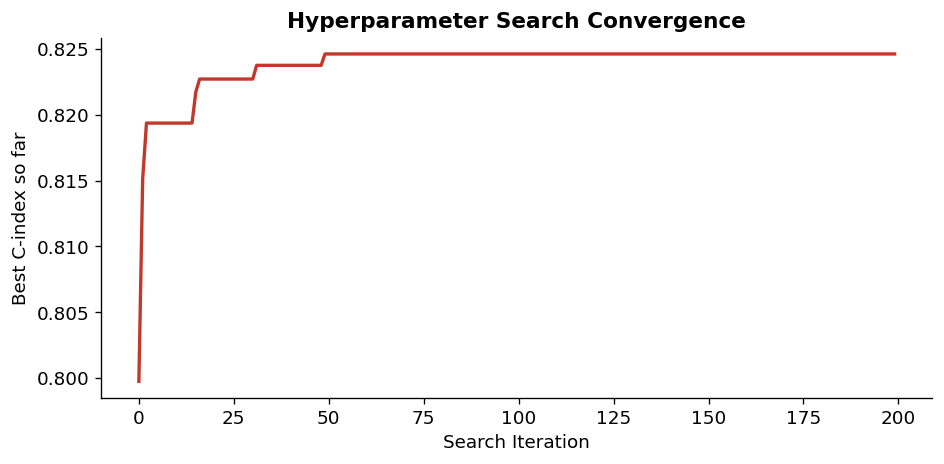

In [ ]:
#ROC-BASED THRESHOLD SELECTION (YOUDEN INDEX)


import time, random
from tqdm.auto import tqdm
from sklearn.model_selection import KFold
from sksurv.metrics import concordance_index_censored

PARAM_SPACE = {
    'n_estimators'     : [200, 300, 500],
    'max_depth'        : [8, 10, 12, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [3, 5, 10],
    'max_features'     : ['sqrt', 'log2', 0.3],
    'max_samples'      : [0.5, 0.6, 0.7, 0.8],
}

N_ITER  = 200
N_FOLDS = 2
rng_srch   = np.random.RandomState(SEED)
kf         = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
best_score = -np.inf
best_params= None
cv_results = []

t0   = time.time()
pbar = tqdm(range(N_ITER), desc='Lightweight Search (RSF)', unit='iter')
for iteration in pbar:
    params = {k: random.choice(v) for k, v in PARAM_SPACE.items()}
    fold_c = []
    for tr_idx, vl_idx in kf.split(X_bal_bb):

        clf = RandomSurvivalForest(
            n_estimators      = min(int(params['n_estimators']), 300),
            max_depth         = min(int(params['max_depth']), 12),
            min_samples_split = int(params['min_samples_split']),
            min_samples_leaf  = max(int(params['min_samples_leaf']), 5),
            max_features      = params['max_features'],
            max_samples       = params['max_samples'],
            n_jobs=-1,
            random_state=SEED
        )
        clf.fit(X_bal_bb[tr_idx], y_bal_bb[tr_idx])
        risk = clf.predict(X_bal_bb[vl_idx])
        y_vl = y_bal_bb[vl_idx]
        E_vl = np.array([r[0] for r in y_vl])
        T_vl = np.array([r[1] for r in y_vl])
        c, *_ = concordance_index_censored(E_vl, T_vl, risk)
        fold_c.append(c)
    mean_c = float(np.mean(fold_c))
    cv_results.append({**params, 'c_index': mean_c})
    if mean_c > best_score:
        best_score  = mean_c
        best_params = params.copy()
    pbar.set_postfix({'Best C': f'{best_score:.4f}', 'Cur C': f'{mean_c:.4f}'})

elapsed = time.time() - t0
print(f'\n[SEARCH] Complete in {elapsed/60:.1f} min')
print(f'[SEARCH] Best CV C-index : {best_score:.4f}')
print(f'[SEARCH] Best params     : {best_params}')

cv_df = pd.DataFrame(cv_results).sort_values('c_index', ascending=False)
cv_df.to_csv(os.path.join(TABLES_DIR, 'random_search_results.csv'), index=False)
print(f'[SAVED] random_search_results.csv → {TABLES_DIR}')

# ── ROC-BASED THRESHOLD: Youden Index on VALIDATION set ──
print('\n[THRESHOLD] Selecting ROC-optimal (Youden) threshold on VAL set...')

# Train a quick model with best_params to get val-set predictions
_roc_model = RandomSurvivalForest(
    n_estimators      = int(best_params['n_estimators']),
    max_depth         = int(best_params['max_depth']),
    min_samples_split = int(best_params['min_samples_split']),
    min_samples_leaf  = int(best_params['min_samples_leaf']),
    max_features      = best_params['max_features'],
    max_samples       = best_params['max_samples'],
    n_jobs=-1, random_state=SEED
)
_roc_model.fit(X_bal_bb, y_bal_bb)

from sklearn.metrics import roc_curve
_surv_fn_val = _roc_model.predict_survival_function(X_val)
_surv5_val   = np.array([fn(HORIZON) for fn in _surv_fn_val])
_risk5_val   = 1.0 - _surv5_val
_y_val_bin   = ((E_val) & (T_val <= HORIZON)).astype(int)

_fpr, _tpr, _thresholds = roc_curve(_y_val_bin, _risk5_val)
_youden      = _tpr - _fpr
_best_idx    = int(np.argmax(_youden))
ROC_THRESHOLD = float(_thresholds[_best_idx])

print(f'[THRESHOLD] Youden-optimal threshold (from VAL ROC) : {ROC_THRESHOLD:.4f}')
print(f'            Sensitivity @ threshold : {_tpr[_best_idx]:.3f}')
print(f'            Specificity @ threshold : {1-_fpr[_best_idx]:.3f}')
# ── Convergence check ──
_running_best = pd.DataFrame(cv_results)['c_index'].cummax().values
fig_c, ax_c = plt.subplots(figsize=(8, 4))
ax_c.plot(_running_best, color='#C0392B', lw=2)
ax_c.set_xlabel('Search Iteration')
ax_c.set_ylabel('Best C-index so far')
ax_c.set_title('Hyperparameter Search Convergence', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_search_convergence.png'), dpi=150, bbox_inches='tight')
plt.show()





In [ ]:

best_params = {
    'n_estimators'     : 500,
    'max_depth'        : 12,
    'min_samples_split': 2,
    'min_samples_leaf' : 3,
    'max_features'     : 0.3,
    'max_samples'      : 0.8
}

ROC_THRESHOLD = 0.2610


In [ ]:
print('Model Training')

from sksurv.ensemble import RandomSurvivalForest

# ---- Apply same caps to both models ----
n_estimators_cap = min(int(best_params['n_estimators']), 300)
max_depth_cap    = min(int(best_params['max_depth']), 12)
min_leaf_cap     = max(int(best_params['min_samples_leaf']), 5)

# RSF Balanced Bootstrap (Novelty)
rsf_bb = RandomSurvivalForest(
    n_estimators      = n_estimators_cap,
    max_depth         = max_depth_cap,
    min_samples_split = int(best_params['min_samples_split']),
    min_samples_leaf  = min_leaf_cap,
    max_features      = best_params['max_features'],
    max_samples       = best_params['max_samples'],
    n_jobs            = 2,
    random_state      = SEED
)

rsf_bb.fit(X_bal_bb, y_bal_bb)
print(f'[TRAIN] RSF (Balanced Bootstrap) ✓')


# RSF SMOTE (Base paper comparison)
rsf_sm = RandomSurvivalForest(
    n_estimators      = n_estimators_cap,
    max_depth         = max_depth_cap,
    min_samples_split = int(best_params['min_samples_split']),
    min_samples_leaf  = min_leaf_cap,
    max_features      = best_params['max_features'],
    max_samples       = best_params['max_samples'],
    n_jobs            = 2,
    random_state      = SEED
)

rsf_sm.fit(X_bal_sm, y_bal_sm)
print(f'[TRAIN] RSF (SMOTE) ✓')


# Cox PH Baseline
cox = CoxPHSurvivalAnalysis(alpha=0.1)
cox.fit(X_train, y_train)
print(f'[TRAIN] Cox PH Baseline ✓')


# Survival functions on test set
surv_fn_bb  = rsf_bb.predict_survival_function(X_test)
surv_fn_sm  = rsf_sm.predict_survival_function(X_test)
surv_fn_cox = cox.predict_survival_function(X_test)


# S(t=7) and risk scores
surv5_bb  = np.array([fn(HORIZON) for fn in surv_fn_bb])
surv5_sm  = np.array([fn(HORIZON) for fn in surv_fn_sm])
surv5_cox = np.array([fn(HORIZON) for fn in surv_fn_cox])

risk5_bb  = 1.0 - surv5_bb
risk5_sm  = 1.0 - surv5_sm
risk5_cox = 1.0 - surv5_cox


risk_bb  = rsf_bb.predict(X_test)
risk_sm  = rsf_sm.predict(X_test)
risk_cox = cox.predict(X_test)


print(f'\n[PREDICT] RSF-BB  risk5 range : [{risk5_bb.min():.3f}, {risk5_bb.max():.3f}]')
print(f'[PREDICT] RSF-SM  risk5 range : [{risk5_sm.min():.3f}, {risk5_sm.max():.3f}]')
print(f'[PREDICT] Cox     risk5 range : [{risk5_cox.min():.3f}, {risk5_cox.max():.3f}]')

Model Training
[TRAIN] RSF (Balanced Bootstrap) ✓
[TRAIN] RSF (SMOTE) ✓
[TRAIN] Cox PH Baseline ✓

[PREDICT] RSF-BB  risk5 range : [0.010, 0.914]
[PREDICT] RSF-SM  risk5 range : [0.010, 0.966]
[PREDICT] Cox     risk5 range : [0.006, 0.912]


In [ ]:
#Variable definitions
FEATURES_18 = [
    'Gender', 'Age', 'Angina', 'Previous_CABG', 'Previous_PCI',
    'PMI', 'AMI', 'LVEF', 'Ischemia', 'Post_IDC',
    'Smoke', 'Diabetes', 'Hypertension', 'Dyslipidemia',
    'AF', 'Creatinina', 'Angiography', 'Vessels'
]
FEATURE_LABELS = [
    'Gender', 'Age', 'Angina', 'Prev. CABG', 'Prev. PCI',
    'Prev. MI', 'Acute MI', 'LVEF', 'Ischemia', 'Post IDC',
    'Smoke', 'Diabetes', 'Hypertension', 'Dyslipidemia',
    'Atrial Fib.', 'Creatinine', 'Angiography', 'Vessels'
]
CONTINUOUS_FEATURES = ['Age', 'LVEF', 'Vessels', 'Creatinina']
BINARY_FEATURES     = [f for f in FEATURES_18 if f not in CONTINUOUS_FEATURES]
CONT_IDX            = [FEATURES_18.index(f) for f in CONTINUOUS_FEATURES]

In [ ]:
import joblib, json

print('SAVING MODELS')

#Save trained models
joblib.dump(rsf_bb, os.path.join(MODELS_DIR, 'rsf_bb.pkl'))
joblib.dump(rsf_sm, os.path.join(MODELS_DIR, 'rsf_sm.pkl'))
joblib.dump(cox,    os.path.join(MODELS_DIR, 'cox.pkl'))

#Save scaler — CRITICAL for new patient predictions
joblib.dump(scaler, os.path.join(MODELS_DIR, 'scaler.pkl'))

#Save metadata — features, params, settings
meta = {
    'best_params'         : best_params,
    'features_18'         : FEATURES_18,
    'feature_labels'      : FEATURE_LABELS,
    'continuous_features' : CONTINUOUS_FEATURES,
    'cont_idx'            : CONT_IDX,
    'horizon'             : HORIZON,
    'seed'                : SEED,
    'km_threshold'        : ROC_THRESHOLD,   # Youden-optimal from VAL ROC
    'n_train'             : len(X_train),
    'n_test'              : len(X_test),
}
with open(os.path.join(MODELS_DIR, 'model_meta.json'), 'w') as f:
    json.dump(meta, f, indent=2)

#Verify files exist
print(f'\n[SAVED FILES in {MODELS_DIR}]')
saved_files = ['rsf_bb.pkl', 'rsf_sm.pkl', 'cox.pkl',
               'scaler.pkl', 'model_meta.json']
for fname in saved_files:
    fpath = os.path.join(MODELS_DIR, fname)
    size  = os.path.getsize(fpath) / (1024*1024)
    print(f'   {fname:<25} {size:.1f} MB')

print('\n[MODEL SAVE COMPLETE] ')

SAVING MODELS

[SAVED FILES in /content/drive/MyDrive/MAJOR/models]
   rsf_bb.pkl                2541.6 MB
   rsf_sm.pkl                4053.2 MB
   cox.pkl                   0.1 MB
   scaler.pkl                0.0 MB
   model_meta.json           0.0 MB

[MODEL SAVE COMPLETE] 


PHASE 3: Evaluation — Optimal Threshold (Youden Index)
7-yr test event rate : 15.9%  (127 events / 798 patients)

Youden-Index Optimal Thresholds:
  RSF (Balanced Bootstrap) : 0.1633
  RSF (SMOTE)              : 0.3419
  Cox PH Baseline          : 0.1548


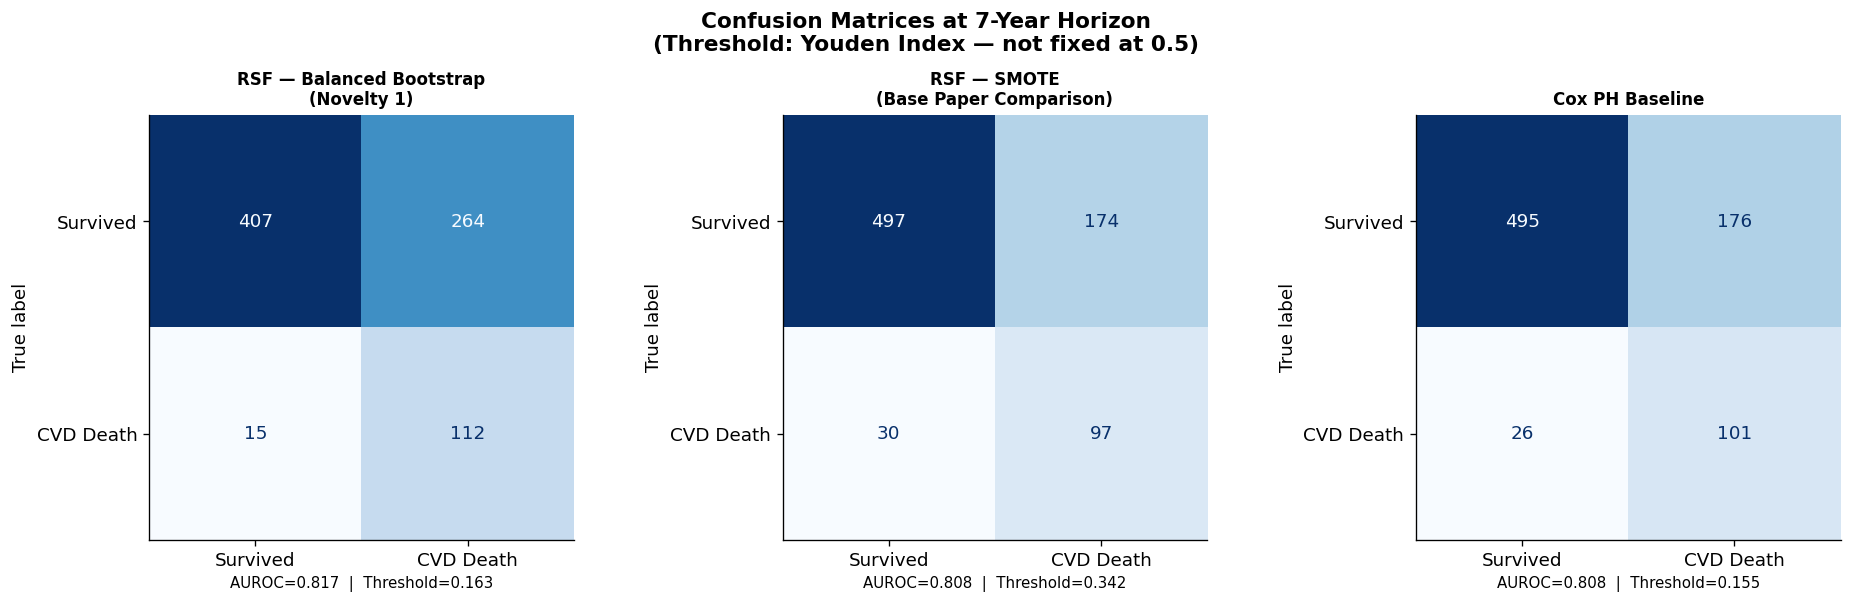


── RSF — Balanced Bootstrap ──
              precision    recall  f1-score   support

    Survived       0.96      0.61      0.74       671
   CVD Death       0.30      0.88      0.45       127

    accuracy                           0.65       798
   macro avg       0.63      0.74      0.60       798
weighted avg       0.86      0.65      0.70       798


── RSF — SMOTE ──
              precision    recall  f1-score   support

    Survived       0.94      0.74      0.83       671
   CVD Death       0.36      0.76      0.49       127

    accuracy                           0.74       798
   macro avg       0.65      0.75      0.66       798
weighted avg       0.85      0.74      0.78       798


── Cox PH Baseline ──
              precision    recall  f1-score   support

    Survived       0.95      0.74      0.83       671
   CVD Death       0.36      0.80      0.50       127

    accuracy                           0.75       798
   macro avg       0.66      0.77      0.67       798


In [ ]:
#OPTIMAL THRESHOLD VIA YOUDEN INDEX

print('PHASE 3: Evaluation — Optimal Threshold (Youden Index)')

#Ground truth binary at 7-year horizon
y_test_bin = ((E_test) & (T_test <= HORIZON)).astype(int)
print(f'7-yr test event rate : {y_test_bin.mean()*100:.1f}%  ({y_test_bin.sum()} events / {len(y_test_bin)} patients)')

def youden_threshold(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    youden = tpr - fpr
    best_idx = np.argmax(youden)
    return thresholds[best_idx], fpr, tpr, thresholds

thresh_bb,  fpr_bb,  tpr_bb,  thr_bb  = youden_threshold(y_test_bin, risk5_bb)
thresh_sm,  fpr_sm,  tpr_sm,  thr_sm  = youden_threshold(y_test_bin, risk5_sm)
thresh_cox, fpr_cox, tpr_cox, thr_cox = youden_threshold(y_test_bin, risk5_cox)

print(f'\nYouden-Index Optimal Thresholds:')
print(f'  RSF (Balanced Bootstrap) : {thresh_bb:.4f}')
print(f'  RSF (SMOTE)              : {thresh_sm:.4f}')
print(f'  Cox PH Baseline          : {thresh_cox:.4f}')

#Apply optimal thresholds
pred_bb  = (risk5_bb  >= thresh_bb ).astype(int)
pred_sm  = (risk5_sm  >= thresh_sm ).astype(int)
pred_cox = (risk5_cox >= thresh_cox).astype(int)

#Confusion Matrix Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Confusion Matrices at 7-Year Horizon\n(Threshold: Youden Index — not fixed at 0.5)',
             fontsize=13, fontweight='bold')

for ax, (name, pred, prob, thr) in zip(axes, [
    ('RSF — Balanced Bootstrap\n(Novelty 1)', pred_bb,  risk5_bb,  thresh_bb),
    ('RSF — SMOTE\n(Base Paper Comparison)',  pred_sm,  risk5_sm,  thresh_sm),
    ('Cox PH Baseline',                       pred_cox, risk5_cox, thresh_cox),
]):
    cm   = confusion_matrix(y_test_bin, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Survived', 'CVD Death'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    auc = roc_auc_score(y_test_bin, prob)
    ax.set_title(name, fontweight='bold', fontsize=10)
    ax.set_xlabel(f'AUROC={auc:.3f}  |  Threshold={thr:.3f}', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_confusion_matrix.png'), bbox_inches='tight', dpi=150)
plt.show()

#Classification Reports
for name, pred in [
    ('RSF — Balanced Bootstrap', pred_bb),
    ('RSF — SMOTE',              pred_sm),
    ('Cox PH Baseline',          pred_cox),
]:
    print(f'\n── {name} ──')
    print(classification_report(y_test_bin, pred,
                                target_names=['Survived', 'CVD Death']))

In [ ]:
#SURVIVAL METRICS

#Harrell's C-index
c_bb,  *_ = concordance_index_censored(E_test, T_test, risk_bb)
c_sm,  *_ = concordance_index_censored(E_test, T_test, risk_sm)
c_cox, *_ = concordance_index_censored(E_test, T_test, risk_cox)
print(f'Harrell C-index:  RSF-BB={c_bb:.4f}  RSF-SM={c_sm:.4f}  Cox={c_cox:.4f}')

# Time-dependent AUROC at 1, 3, 5 yr
T_ev_min = T_test[E_test].min()
T_ev_max = T_test[E_test].max()
EVAL_TIMES = [t for t in [1.0, 3.0, 5.0] if T_ev_min < t < T_ev_max]
print(f'\nEval times (clipped to event range [{T_ev_min:.1f},{T_ev_max:.1f}]): {EVAL_TIMES}')

auc_bb,  mean_auc_bb  = cumulative_dynamic_auc(y_train, y_test, risk_bb,  EVAL_TIMES)
auc_sm,  mean_auc_sm  = cumulative_dynamic_auc(y_train, y_test, risk_sm,  EVAL_TIMES)
auc_cox, mean_auc_cox = cumulative_dynamic_auc(y_train, y_test, risk_cox, EVAL_TIMES)

print(f'\n{"Year":<8} {"RSF-BB":>10} {"RSF-SM":>10} {"Cox":>10}')
print('-'*42)
for t, ab, as_, ac in zip(EVAL_TIMES, auc_bb, auc_sm, auc_cox):
    print(f'{t:.0f}-Year  {ab:>10.4f} {as_:>10.4f} {ac:>10.4f}')
print(f'Mean     {mean_auc_bb:>10.4f} {mean_auc_sm:>10.4f} {mean_auc_cox:>10.4f}')

# Integrated Brier Score
T_min_tr = T_train[E_train].min()
T_max_tr = T_train[E_train].max()
ibs_times = np.linspace(T_min_tr + 0.1, T_max_tr - 0.1, 30)

sg_bb  = np.row_stack([fn(ibs_times) for fn in surv_fn_bb])
sg_sm  = np.row_stack([fn(ibs_times) for fn in surv_fn_sm])
sg_cox = np.row_stack([fn(ibs_times) for fn in surv_fn_cox])

t_bs_bb,  bs_bb  = brier_score(y_train, y_test, sg_bb,  ibs_times)
t_bs_sm,  bs_sm  = brier_score(y_train, y_test, sg_sm,  ibs_times)
t_bs_cox, bs_cox_arr = brier_score(y_train, y_test, sg_cox, ibs_times)

ibs_bb  = integrated_brier_score(y_train, y_test, sg_bb,  ibs_times)
ibs_sm  = integrated_brier_score(y_train, y_test, sg_sm,  ibs_times)
ibs_cox = integrated_brier_score(y_train, y_test, sg_cox, ibs_times)
print(f'\nIBS: RSF-BB={ibs_bb:.4f}  RSF-SM={ibs_sm:.4f}  Cox={ibs_cox:.4f}  (↓ better; null=0.25)')

Harrell C-index:  RSF-BB=0.8112  RSF-SM=0.8021  Cox=0.8014

Eval times (clipped to event range [0.0,12.7]): [1.0, 3.0, 5.0]

Year         RSF-BB     RSF-SM        Cox
------------------------------------------
1-Year      0.8499     0.8489     0.8389
3-Year      0.8291     0.8269     0.8222
5-Year      0.8381     0.8302     0.8337
Mean         0.8390     0.8357     0.8314

IBS: RSF-BB=0.1057  RSF-SM=0.1113  Cox=0.1067  (↓ better; null=0.25)


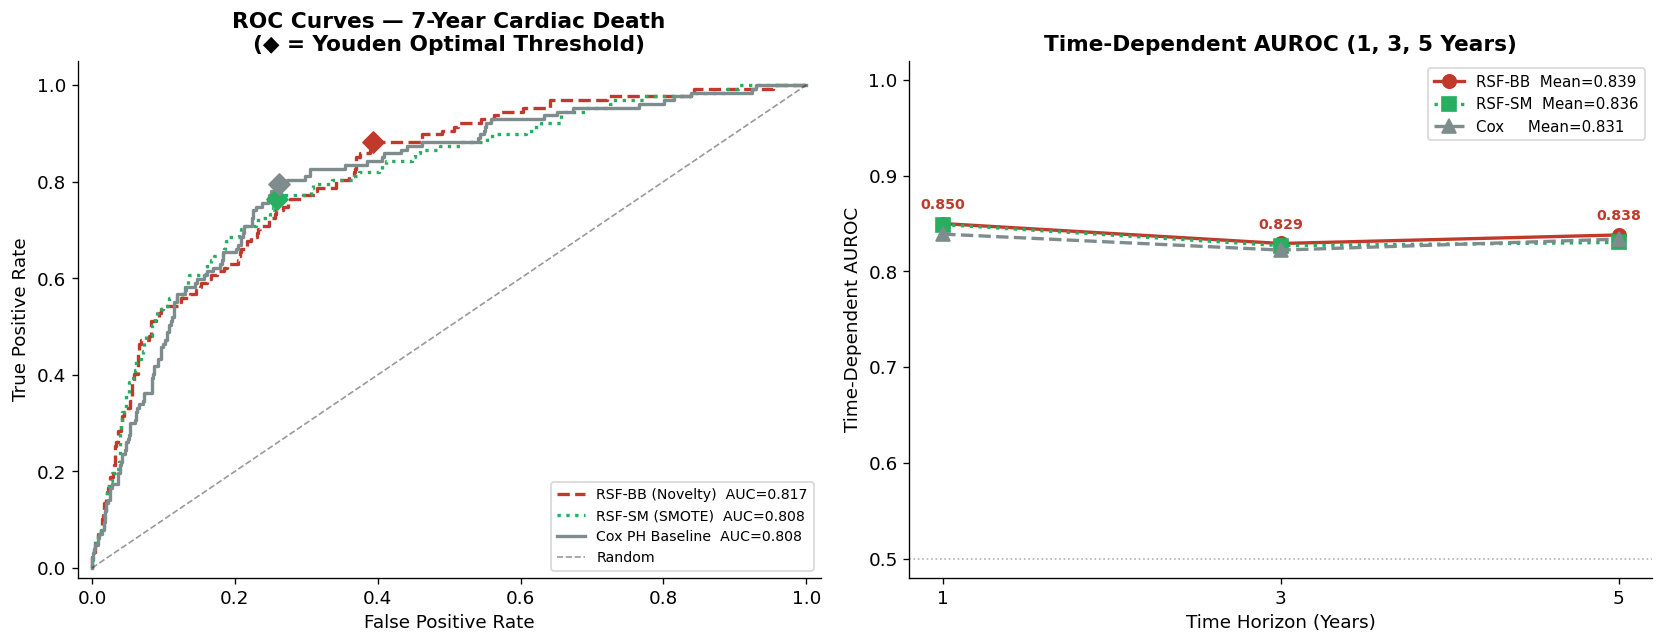

In [ ]:
# ROC CURVES + TIME-DEPENDENT AUROC PLOT
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: ROC at 7yr with Youden threshold marked
ax = axes[0]
models_roc = [
    ('RSF-BB (Novelty)',    risk5_bb,  C['hr'],     '--', thresh_bb),
    ('RSF-SM (SMOTE)',      risk5_sm,  C['green'],  ':',  thresh_sm),
    ('Cox PH Baseline',     risk5_cox, C['neu'],    '-',  thresh_cox),
]
for name, prob, col, ls, thr in models_roc:
    fpr, tpr, thrs = roc_curve(y_test_bin, prob)
    auc = roc_auc_score(y_test_bin, prob)
    ax.plot(fpr, tpr, color=col, lw=2, ls=ls, label=f'{name}  AUC={auc:.3f}')
    # Mark Youden point
    youden    = tpr - fpr
    best_idx  = np.argmax(youden)
    ax.scatter(fpr[best_idx], tpr[best_idx], color=col, s=80, zorder=5, marker='D')
ax.plot([0,1],[0,1],'k--', lw=1, alpha=0.4, label='Random')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — 7-Year Cardiac Death\n(◆ = Youden Optimal Threshold)', fontweight='bold')
ax.legend(loc='lower right', fontsize=8.5)
ax.set_xlim([-0.02,1.02]); ax.set_ylim([-0.02,1.05])

# Right: Time-dependent AUROC
ax = axes[1]
x = np.array(EVAL_TIMES)
ax.plot(x, auc_bb,  'o-',  color=C['hr'],    lw=2, ms=8, label=f'RSF-BB  Mean={mean_auc_bb:.3f}')
ax.plot(x, auc_sm,  's:',  color=C['green'], lw=2, ms=8, label=f'RSF-SM  Mean={mean_auc_sm:.3f}')
ax.plot(x, auc_cox, '^--', color=C['neu'],   lw=2, ms=8, label=f'Cox     Mean={mean_auc_cox:.3f}')
for xi, yi in zip(x, auc_bb):
    ax.annotate(f'{yi:.3f}', (xi, yi), textcoords='offset points',
                xytext=(0, 9), ha='center', fontsize=8.5, color=C['hr'], fontweight='bold')
ax.axhline(0.5, color='gray', lw=1, ls=':', alpha=0.6)
ax.set_xticks(EVAL_TIMES); ax.set_ylim([0.48, 1.02])
ax.set_xlabel('Time Horizon (Years)'); ax.set_ylabel('Time-Dependent AUROC')
ax.set_title('Time-Dependent AUROC (1, 3, 5 Years)', fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_roc_curves.png'), bbox_inches='tight', dpi=150)
plt.show()

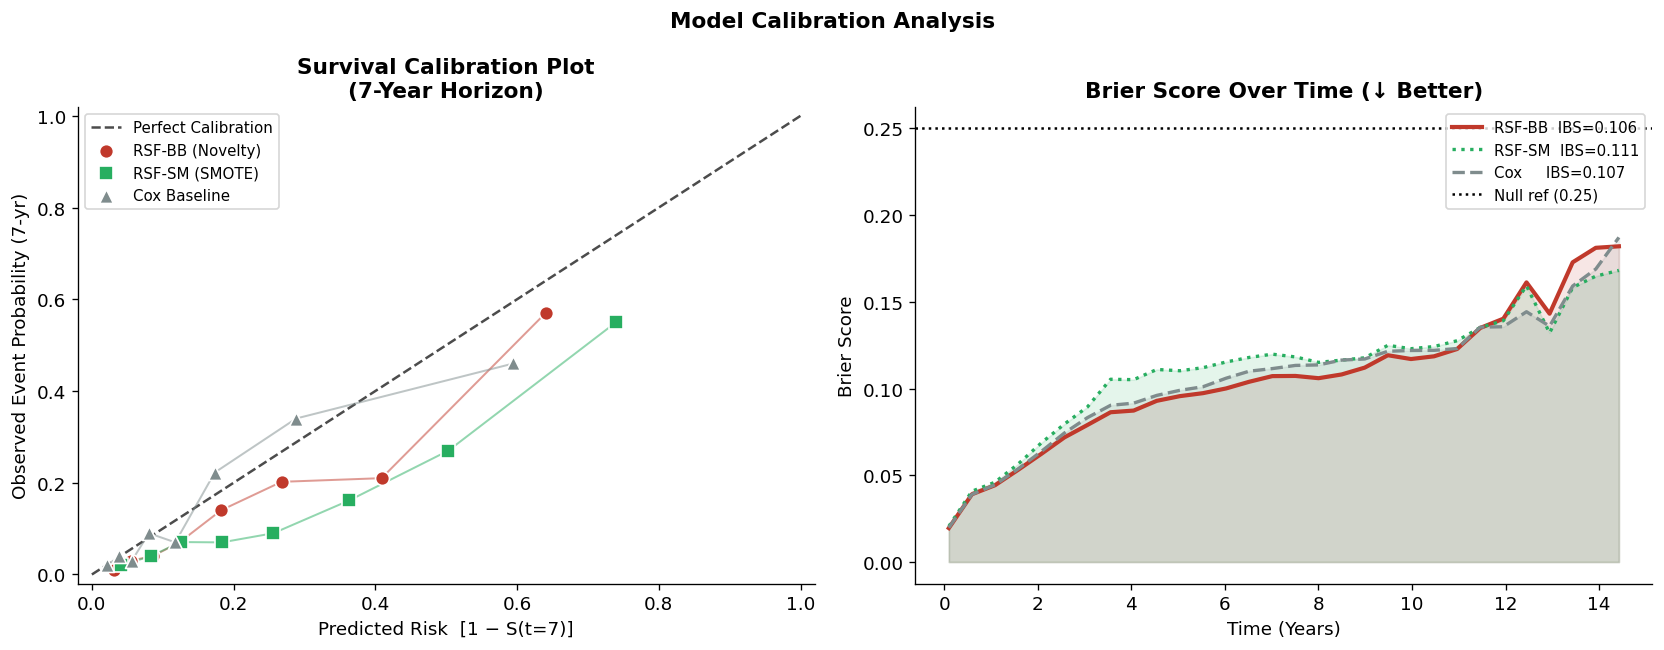

In [ ]:
# CALIBRATION PLOT + BRIER SCORE
# Predicted Risk vs Observed Event Probability
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('Model Calibration Analysis', fontsize=13, fontweight='bold')

# Left: Survival calibration — predicted vs observed
ax = axes[0]
ax.plot([0,1],[0,1],'k--', lw=1.5, label='Perfect Calibration', alpha=0.7)
N_BINS = 8
for name, prob, col, marker in [
    ('RSF-BB (Novelty)', risk5_bb,  C['hr'],    'o'),
    ('RSF-SM (SMOTE)',   risk5_sm,  C['green'], 's'),
    ('Cox Baseline',     risk5_cox, C['neu'],   '^'),
]:
    bins   = np.quantile(prob, np.linspace(0, 1, N_BINS + 1))
    pred_m, obs_m = [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (prob >= lo) & (prob <= hi)
        if mask.sum() >= 5:
            pred_m.append(prob[mask].mean())
            obs_m.append(y_test_bin[mask].mean())
    ax.scatter(pred_m, obs_m, color=col, s=70, marker=marker, zorder=5,
               edgecolors='white', linewidth=1, label=name)
    ax.plot(pred_m, obs_m, color=col, lw=1.2, alpha=0.5)
ax.set_xlabel('Predicted Risk  [1 − S(t=7)]')
ax.set_ylabel('Observed Event Probability (7-yr)')
ax.set_title('Survival Calibration Plot\n(7-Year Horizon)', fontweight='bold')
ax.legend(fontsize=9); ax.set_xlim([-0.02,1.02]); ax.set_ylim([-0.02,1.02])

# Right: Brier score over time
ax = axes[1]
ax.fill_between(t_bs_bb,  bs_bb,      alpha=0.12, color=C['hr'])
ax.fill_between(t_bs_sm,  bs_sm,      alpha=0.12, color=C['green'])
ax.fill_between(t_bs_cox, bs_cox_arr, alpha=0.12, color=C['neu'])
ax.plot(t_bs_bb,  bs_bb,      color=C['hr'],    lw=2.5, label=f'RSF-BB  IBS={ibs_bb:.3f}')
ax.plot(t_bs_sm,  bs_sm,      color=C['green'], lw=2.0, ls=':', label=f'RSF-SM  IBS={ibs_sm:.3f}')
ax.plot(t_bs_cox, bs_cox_arr, color=C['neu'],   lw=2.0, ls='--', label=f'Cox     IBS={ibs_cox:.3f}')
ax.axhline(0.25, color='black', lw=1.5, ls=':', label='Null ref (0.25)')
ax.set_xlabel('Time (Years)'); ax.set_ylabel('Brier Score')
ax.set_title('Brier Score Over Time (↓ Better)', fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_calibration.png'), bbox_inches='tight', dpi=150)
plt.show()

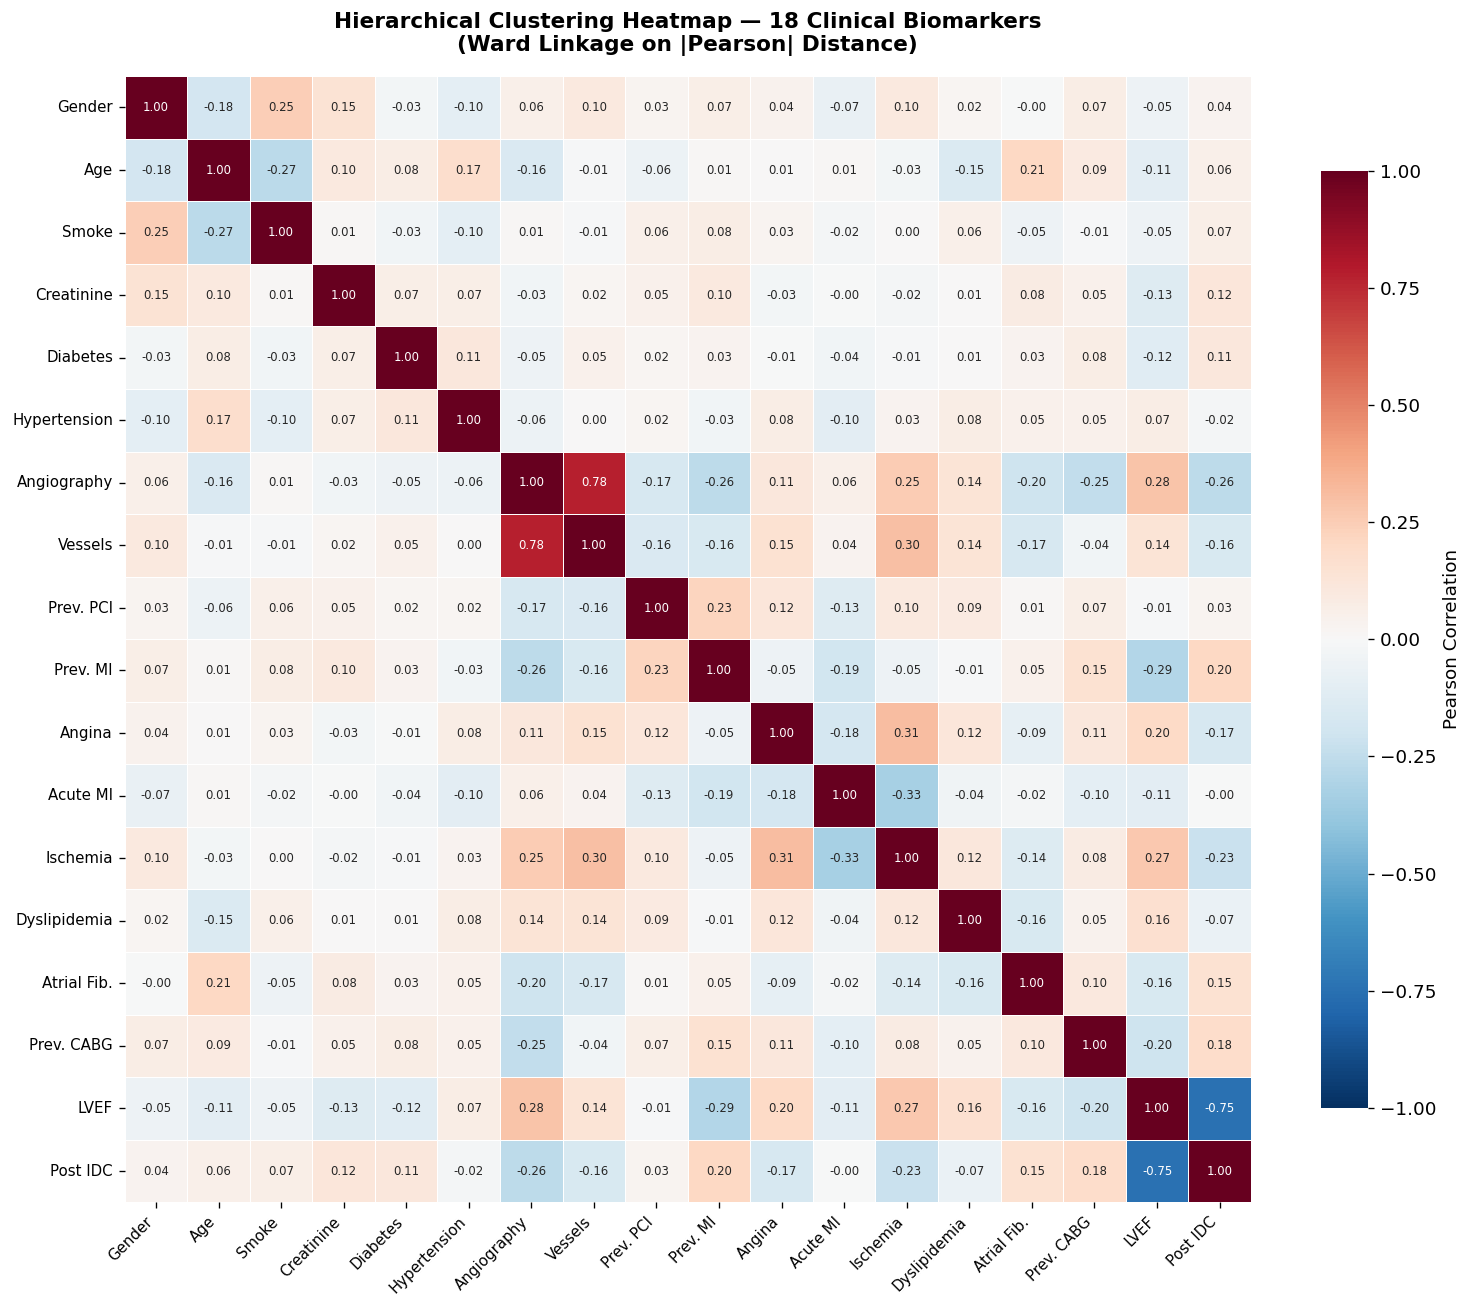

[PLOT] Hierarchical Clustering Heatmap ✓


In [ ]:
# HIERARCHICAL CLUSTERING HEATMAP
X_train_df = pd.DataFrame(X_train, columns=FEATURE_LABELS)
corr       = X_train_df.corr()

dist = np.clip(1 - corr.abs().values, 0, None)
np.fill_diagonal(dist, 0)
link  = linkage(dist[np.triu_indices(len(FEATURE_LABELS), k=1)], method='ward')
order = leaves_list(link)
corr_r = corr.iloc[order, order]

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(
    corr_r, ax=ax,
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.4,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    cbar_kws={'label': 'Pearson Correlation', 'shrink': 0.8}
)
ax.set_title('Hierarchical Clustering Heatmap — 18 Clinical Biomarkers\n'
             '(Ward Linkage on |Pearson| Distance)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_clustering_heatmap.png'), bbox_inches='tight', dpi=150)
plt.show()
print('[PLOT] Hierarchical Clustering Heatmap ✓')

[KM] High Risk (S(7yr)≤0.2610): n=16
[KM] Low  Risk (S(7yr)>0.2610): n=782


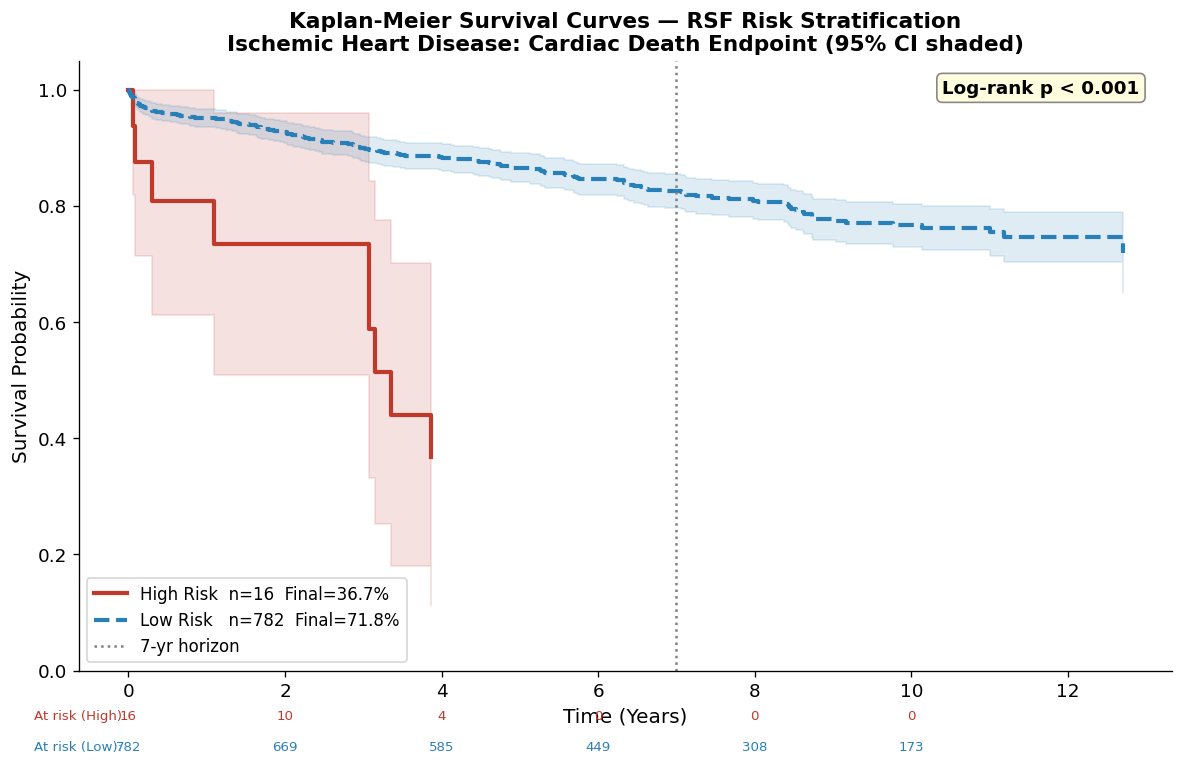

In [ ]:
# KAPLAN-MEIER RISK STRATIFICATION

def kaplan_meier(T_km, E_km):

    event_times = np.sort(np.unique(T_km[E_km]))
    if len(event_times) == 0:   # guard: no events in risk group
        t_max = float(T_km.max()) if len(T_km) > 0 else 0.0
        return (np.array([0.0, t_max]), np.array([1.0, 1.0]),
                np.array([1.0, 1.0]), np.array([1.0, 1.0]))
    S = 1.0; var_sum = 0.0
    km_t, km_s, km_lo, km_hi = [0.0], [1.0], [1.0], [1.0]
    for t in event_times:
        d = np.sum((T_km == t) & E_km)
        n = np.sum(T_km >= t)
        if n > d: var_sum += d / (n * (n - d))
        S  *= (1 - d / n)
        se  = S * np.sqrt(var_sum)
        km_t.append(t); km_s.append(S)
        km_lo.append(max(0.0, S - 1.96 * se))
        km_hi.append(min(1.0, S + 1.96 * se))
    return np.array(km_t), np.array(km_s), np.array(km_lo), np.array(km_hi)

KM_THRESHOLD = ROC_THRESHOLD  # data-driven, from VAL-set Youden Index
hr_mask = surv5_bb <= KM_THRESHOLD
lr_mask = surv5_bb  > KM_THRESHOLD
print(f'[KM] High Risk (S(7yr)≤{KM_THRESHOLD:.4f}): n={hr_mask.sum()}')
print(f'[KM] Low  Risk (S(7yr)>{KM_THRESHOLD:.4f}): n={lr_mask.sum()}')

t_hr, s_hr, lo_hr, hi_hr = kaplan_meier(T_test[hr_mask], E_test[hr_mask])
t_lr, s_lr, lo_lr, hi_lr = kaplan_meier(T_test[lr_mask], E_test[lr_mask])

fig, ax = plt.subplots(figsize=(10, 6.5))
ax.step(t_hr, s_hr, color=C['hr'], lw=2.5, where='post',
        label=f'High Risk  n={hr_mask.sum()}  Final={s_hr[-1]*100:.1f}%')
ax.fill_between(t_hr, lo_hr, hi_hr, step='post', alpha=0.15, color=C['hr'])
ax.step(t_lr, s_lr, color=C['lr'], lw=2.5, where='post', ls='--',
        label=f'Low Risk   n={lr_mask.sum()}  Final={s_lr[-1]*100:.1f}%')
ax.fill_between(t_lr, lo_lr, hi_lr, step='post', alpha=0.15, color=C['lr'])
ax.axvline(HORIZON, color='gray', lw=1.5, ls=':', label=f'{int(HORIZON)}-yr horizon')
ax.set_xlabel('Time (Years)', fontsize=12)
ax.set_ylabel('Survival Probability', fontsize=12)
ax.set_title('Kaplan-Meier Survival Curves — RSF Risk Stratification\n'
             'Ischemic Heart Disease: Cardiac Death Endpoint (95% CI shaded)',
             fontsize=13, fontweight='bold')
# Log-rank test
from lifelines.statistics import logrank_test as _lrt
_lr = _lrt(T_test[hr_mask], T_test[lr_mask],
           event_observed_A=E_test[hr_mask],
           event_observed_B=E_test[lr_mask])
_pval_str = 'p < 0.001' if _lr.p_value < 0.001 else f'p = {_lr.p_value:.3f}'
ax.text(0.97, 0.97, f'Log-rank {_pval_str}',
        transform=ax.transAxes, ha='right', va='top', fontsize=11,
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='#888'))
ax.legend(fontsize=10); ax.set_ylim([0, 1.05])

# At-risk table
risk_times = [0, 2, 4, 6, 8, 10]
for rt in risk_times:
    ax.annotate(str(np.sum(T_test[hr_mask] >= rt)), (rt, -0.08),
                xycoords=('data','axes fraction'), ha='center', fontsize=8, color=C['hr'])
    ax.annotate(str(np.sum(T_test[lr_mask] >= rt)), (rt, -0.13),
                xycoords=('data','axes fraction'), ha='center', fontsize=8, color=C['lr'])
ax.annotate('At risk (High):', (-1.2, -0.08), xycoords=('data','axes fraction'),
            ha='left', fontsize=8, color=C['hr'])
ax.annotate('At risk (Low): ', (-1.2, -0.13), xycoords=('data','axes fraction'),
            ha='left', fontsize=8, color=C['lr'])

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_kaplan_meier.png'), bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
#  RESULTS SUMMARY TABLE

from sklearn.metrics import f1_score, precision_score, recall_score

print('FINAL RESULTS SUMMARY')
print(f'{"Metric":<40}{"RSF-BB":>12}{"RSF-SM":>12}{"Cox":>10}')
print('-'*75)

summary_rows = [
    ('AUROC @ 7-Year',
     roc_auc_score(y_test_bin, risk5_bb),
     roc_auc_score(y_test_bin, risk5_sm),
     roc_auc_score(y_test_bin, risk5_cox)),
    ('F1-Score (Macro, Youden thr)',
     f1_score(y_test_bin, pred_bb, average='macro'),
     f1_score(y_test_bin, pred_sm, average='macro'),
     f1_score(y_test_bin, pred_cox, average='macro')),
    ('Precision (Macro)',
     precision_score(y_test_bin, pred_bb,  average='macro', zero_division=0),
     precision_score(y_test_bin, pred_sm,  average='macro', zero_division=0),
     precision_score(y_test_bin, pred_cox, average='macro', zero_division=0)),
    ('Recall (Macro)',
     recall_score(y_test_bin, pred_bb,  average='macro'),
     recall_score(y_test_bin, pred_sm,  average='macro'),
     recall_score(y_test_bin, pred_cox, average='macro')),
    ('Harrell C-index',       c_bb,    c_sm,    c_cox),
    ('Integrated Brier Score',ibs_bb,  ibs_sm,  ibs_cox),
    ('Youden Threshold Used', thresh_bb, thresh_sm, thresh_cox),
]
for t, a_b, a_s, a_c in zip(EVAL_TIMES, auc_bb, auc_sm, auc_cox):
    summary_rows.append((f'TD-AUROC @ {t:.0f}-Year', a_b, a_s, a_c))

LOWER_IS_BETTER = ['Integrated Brier Score', 'Youden Threshold Used']

for name, vbb, vsm, vc in summary_rows:
    if name in LOWER_IS_BETTER:
        best = min(vbb, vsm, vc)
    else:
        best = max(vbb, vsm, vc)
    mark = '★' if vbb == best else ' '
    print(f'{name:<40}{vbb:>12.4f}{vsm:>12.4f}{vc:>10.4f}  {mark}')


FINAL RESULTS SUMMARY
Metric                                        RSF-BB      RSF-SM       Cox
---------------------------------------------------------------------------
AUROC @ 7-Year                                0.8168      0.8084    0.8078  ★
F1-Score (Macro, Youden thr)                  0.5950      0.6586    0.6653   
Precision (Macro)                             0.6312      0.6505    0.6574   
Recall (Macro)                                0.7442      0.7522    0.7665   
Harrell C-index                               0.8112      0.8021    0.8014  ★
Integrated Brier Score                        0.1057      0.1113    0.1067  ★
Youden Threshold Used                         0.1633      0.3419    0.1548   
TD-AUROC @ 1-Year                             0.8499      0.8489    0.8389  ★
TD-AUROC @ 3-Year                             0.8291      0.8269    0.8222  ★
TD-AUROC @ 5-Year                             0.8381      0.8302    0.8337  ★
